# clustering

In [ ]:
# import modules
import pandas as pd
import numpy as np

# preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# cluster
from sklearn.cluster import KMeans

# metrics
from sklearn.metrics import silhouette_score


In [2]:
df = pd.read_pickle("C:/Users/heike/Desktop/Stackfuel/Portfolio/llm-sustainability-analysis/01_data/03_features/conversation_features.pkl")

### train test split

In [3]:
df.dtypes

conversation_id                          str
first_prompt                             str
first_prompt_tokens                    int64
total_turns                            int64
interaction_rounds                   float64
follow_up_prompts                      int64
total_user_tokens                      int64
total_assistant_tokens                 int64
total_tokens                           int64
has_role_instruction                   int64
has_audience_or_level_instruction      int64
has_format_instruction                 int64
question_count                         int64
prompt_style                             str
orthographic_error_rate              float64
task_type                                str
needs_follow_up                        int64
topic_id                               int64
topic_label                              str
quality                                  str
quality_score                        float64
task_bucket                              str
long_conte

In [15]:
df["task_type"] = df["task_type"].astype("category")
df["prompt_style"] = df["prompt_style"].astype("category")
df["topic_label"] = df["topic_label"].astype("category")
df["task_bucket"] = df["task_bucket"].astype("category")

In [16]:
# features selection

FEATURES_SELECTED = {
    'cat': [
        "task_type",
        "topic_label",
        "prompt_style",
        "task_bucket"        
        ],
    'num': [
        "first_prompt_tokens",
        "total_user_tokens",
        "total_tokens",
        "total_turns",
        "interaction_rounds",
        "orthographic_error_rate",
        "question_count",
        "needs_follow_up",
        ],
    'bin': [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction"]
}

In [69]:
# preprocessing

model_KMeans = KMeans(n_clusters=5)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipe, FEATURES_SELECTED['cat']),
    ('num', num_pipe, FEATURES_SELECTED['num']),
    ('bin', 'passthrough', FEATURES_SELECTED['bin'])
])


# model

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model_KMeans)
])

In [70]:
df["user_cluster"] = pipeline.fit_predict(df)

<Axes: xlabel='user_cluster'>

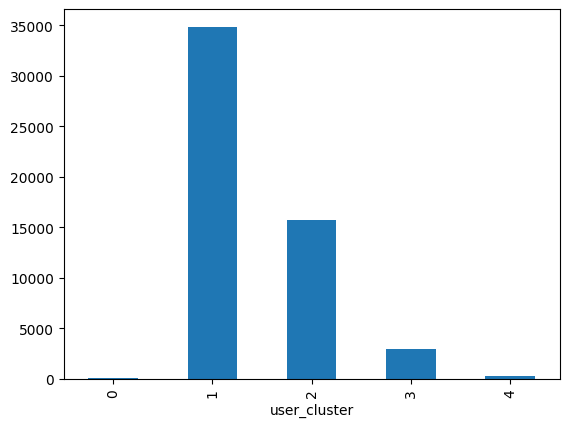

In [71]:
df["user_cluster"].value_counts().sort_index().plot(kind="bar")

In [72]:
cluster_profile = (
    df.groupby("user_cluster")
    .agg(
        total_tokens=("total_tokens", "mean"),
        total_turns=("total_turns", "mean"),
        interaction_rounds=("interaction_rounds", "mean"),
        question_count=("question_count", "mean"),
        orthographic_error_rate=("orthographic_error_rate", "mean"),
        quality_score=("quality_score", "mean"),
        has_role_instruction=("has_role_instruction", "mean"),
        has_format_instruction=("has_format_instruction", "mean"),
        cluster_size=("user_cluster", "size"),
    )
    .round(2)
)

cluster_profile

,total_tokens,total_turns,interaction_rounds,question_count,orthographic_error_rate,quality_score,has_role_instruction,has_format_instruction,cluster_size
user_cluster,,,,,,,,,
0,25920.29,18.41,9.21,94.53,0.02,11.92,0.68,0.94,34
1,3626.73,13.21,6.61,0.53,0.05,1.59,0.13,0.23,34854
2,734.41,1.93,0.96,0.70,0.05,1.69,0.12,0.26,15720
3,23741.16,81.24,40.62,0.61,0.05,1.82,0.16,0.30,2984
4,106710.15,314.31,157.15,0.56,0.05,3.03,0.16,0.29,232


In [73]:
task_modes = (
    df.groupby("user_cluster")["task_type"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "unknown")
)

In [74]:
topic_modes = (
    df.groupby("user_cluster")["topic_label"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "unknown")
)

In [75]:
cluster_profile["main_task"] = task_modes
cluster_profile["main_topic"] = topic_modes

In [76]:
def generate_cluster_label(row):

    # -------------------------
    # Coding users
    # -------------------------
    if row["main_task"] == "coding":
        if row["total_tokens"] > 5000:
            return "Code Power Users"
        return "Coding Assistance Users"

    # -------------------------
    # Prompt engineers
    # -------------------------
    if (
        row["has_role_instruction"] > 0.5
        or row["has_format_instruction"] > 0.5
    ):
        return "Structured Prompt Engineers"

    # -------------------------
    # Long-context users
    # -------------------------
    if row["total_tokens"] > 4000:
        return "Long Context Users"

    # -------------------------
    # QA-style users
    # -------------------------
    if row["question_count"] > 2:
        return "Question-Heavy Users"

    # -------------------------
    # Low-quality users
    # -------------------------
    if row["quality_score"] < 0:
        return "Low Quality / Noisy Users"

    # -------------------------
    # Default
    # -------------------------
    return "General Assistance Users"

In [77]:
cluster_profile["cluster_label"] = cluster_profile.apply(
    generate_cluster_label,
    axis=1
)

In [78]:
cluster_profile[
    [
        "cluster_label",
        "main_task",
        "main_topic",
        "total_tokens",
        "quality_score"
    ]
]

,cluster_label,main_task,main_topic,total_tokens,quality_score
user_cluster,,,,,
0,Code Power Users,coding,general_business_assistance,25920.29,11.92
1,General Assistance Users,general_assistance,general_business_assistance,3626.73,1.59
2,General Assistance Users,general_assistance,general_business_assistance,734.41,1.69
3,Long Context Users,general_assistance,general_business_assistance,23741.16,1.82
4,Long Context Users,general_assistance,general_business_assistance,106710.15,3.03
